# So sánh tất cả model PhilosophyMT

Notebook này đọc `runs/*/eval_metrics.json` và `runs/*/predictions_test.jsonl`, sau đó tổng hợp BLEU, chrF++ và các mẫu dịch. COMET đã được bỏ khỏi notebook vì dependency không ổn định trên môi trường hiện tại.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

COLAB_ROOT = Path('/content/drive/MyDrive/PhilosophyMT')
if COLAB_ROOT.exists():
    DRIVE_ROOT = COLAB_ROOT
elif Path.cwd().name == 'notebooks':
    DRIVE_ROOT = Path.cwd().parent
else:
    DRIVE_ROOT = Path.cwd()

RUNS_DIR = DRIVE_ROOT / 'runs'
print(f'RUNS_DIR: {RUNS_DIR}')


RUNS_DIR: e:\PhilosophyMT\runs


## 1. Load metrics


In [2]:
rows = []
for metrics_path in sorted(RUNS_DIR.glob('*/eval_metrics.json')):
    with open(metrics_path, 'r', encoding='utf-8') as f:
        metrics = json.load(f)

    run_id = metrics.get('run_id', metrics_path.parent.name)
    test = metrics.get('test', {})
    val = metrics.get('val', {})
    rows.append(
        {
            'run_id': run_id,
            'model_name': metrics.get('model_name'),
            'method': metrics.get('method'),
            'learning_rate': metrics.get('learning_rate'),
            'max_source_length': metrics.get('max_source_length'),
            'max_target_length': metrics.get('max_target_length'),
            'max_seq_length': metrics.get('max_seq_length'),
            'max_new_tokens': metrics.get('max_new_tokens'),
            'eval_batch_size': metrics.get('eval_batch_size'),
            'val_bleu': val.get('bleu'),
            'val_chrf': val.get('chrf'),
            'test_bleu': test.get('bleu'),
            'test_chrf': test.get('chrf'),
            'metrics_path': str(metrics_path),
        }
    )

summary_df = pd.DataFrame(rows)
if summary_df.empty:
    print('No runs/*/eval_metrics.json found.')
else:
    display(summary_df.sort_values('test_chrf', ascending=False, na_position='last'))

,run_id,model_name,method,learning_rate,max_source_length,max_target_length,max_seq_length,val_bleu,val_chrf,val_comet,test_bleu,test_chrf,test_comet,metrics_path
0,marian_baseline,Helsinki-NLP/opus-mt-en-vi,baseline,NaN,NaN,NaN,NaN,NaN,NaN,None,11.6533,31.1529,None,e:\PhilosophyMT\runs\marian_baseline\eval_metr...
1,marian_lr1e-5,Helsinki-NLP/opus-mt-en-vi,full_finetune,0.00001,320.0,320.0,NaN,39.8820,58.4052,None,39.3259,59.0951,None,e:\PhilosophyMT\runs\marian_lr1e-5\eval_metric...
2,marian_lr3e-5,Helsinki-NLP/opus-mt-en-vi,full_finetune,0.00003,320.0,320.0,NaN,45.3846,62.6376,None,45.8165,64.0285,None,e:\PhilosophyMT\runs\marian_lr3e-5\eval_metric...
3,marian_lr5e-5,Helsinki-NLP/opus-mt-en-vi,full_finetune,0.00005,320.0,320.0,NaN,47.5904,64.3737,None,48.4134,65.8429,None,e:\PhilosophyMT\runs\marian_lr5e-5\eval_metric...
4,qwen25_0_5b_base,Qwen/Qwen2.5-0.5B-Instruct,base_no_finetune,NaN,NaN,NaN,1024.0,10.7835,29.5578,None,8.6148,27.3461,None,e:\PhilosophyMT\runs\qwen25_0_5b_base\eval_met...
5,qwen25_0_5b_qlora,Qwen/Qwen2.5-0.5B-Instruct,qlora_4bit,0.00020,NaN,NaN,1024.0,43.4027,60.7321,None,44.1168,62.1533,None,e:\PhilosophyMT\runs\qwen25_0_5b_qlora\eval_me...


## 2. Biểu đồ metric


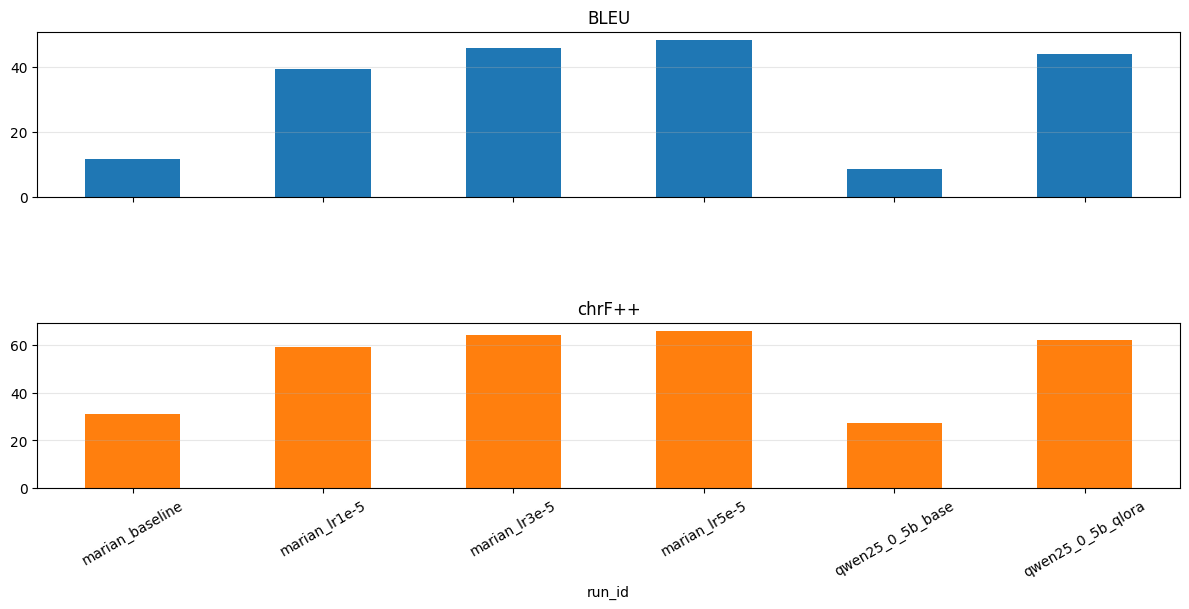

In [3]:
if not summary_df.empty:
    metric_cols = [col for col in ['test_bleu', 'test_chrf'] if col in summary_df.columns]
    plot_df = summary_df.set_index('run_id')[metric_cols]
    axes = plot_df.plot(
        kind='bar',
        subplots=True,
        figsize=(12, 6),
        legend=False,
        layout=(len(metric_cols), 1),
        rot=30,
    )
    if len(metric_cols) == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    for ax, title in zip(axes, ['BLEU', 'chrF++']):
        ax.set_title(title)
        ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

## 3. Load predictions


In [4]:
def load_predictions(run_id):
    path = RUNS_DIR / run_id / 'predictions_test.jsonl'
    if not path.exists():
        return pd.DataFrame()

    records = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))

    df = pd.DataFrame(records)
    if not df.empty:
        df['run_id'] = run_id
    return df


all_predictions = (
    pd.concat(
        [load_predictions(run_id) for run_id in summary_df['run_id']],
        ignore_index=True,
    )
    if not summary_df.empty
    else pd.DataFrame()
)

print(f'Loaded predictions: {len(all_predictions):,}')
if not all_predictions.empty:
    display(all_predictions.head())


Loaded predictions: 1,824


,id,topic,source,reference,prediction,run_id
0,118,Benedict de Spinoza: Epistemology,"The theory of knowledge, or epistemology , off...","Lý thuyết về nhận thức, hay nhận thức luận, đư...","Lý thuyết về kiến thức, hay thuật ngữ, được đư...",marian_baseline
1,119,Benedict de Spinoza: Epistemology,Of the philosophers who have claimed absolute ...,Trong số các triết gia từng tuyên bố về tri th...,Trong số các nhà khảo cổ học đã thuyết phục đư...,marian_baseline
2,120,Benedict de Spinoza: Epistemology,"However, whether or not Spinoza’s epistemology...","Tuy nhiên, việc nhận thức luận của Spinoza có ...","Tuy nhiên, dù các triết gia của ông Spinoemolo...",marian_baseline
3,121,Benedict de Spinoza: Epistemology,Spinoza’s philosophy as a whole can be seen as...,"Triết học của Spinoza, xét như một toàn thể, c...","Là một nhà lý luận, cùng với triết lý của ông ...",marian_baseline
4,122,Benedict de Spinoza: Epistemology,Spinoza sees the obtaining of true knowledge t...,Spinoza xem việc đạt được tri thức chân thực l...,Spinoza nhận thấy rằng việc đạt được sự hiểu b...,marian_baseline


## 4. Translation samples


In [6]:
if not all_predictions.empty:
    sample_cols = ['run_id', 'topic', 'source', 'reference', 'prediction']
    for run_id in all_predictions['run_id'].unique():
        print('=' * 90)
        print(run_id)
        display(
            all_predictions[all_predictions['run_id'] == run_id][sample_cols].head(3)
        )


marian_baseline


,run_id,topic,source,reference,prediction
0,marian_baseline,Benedict de Spinoza: Epistemology,"The theory of knowledge, or epistemology , off...","Lý thuyết về nhận thức, hay nhận thức luận, đư...","Lý thuyết về kiến thức, hay thuật ngữ, được đư..."
1,marian_baseline,Benedict de Spinoza: Epistemology,Of the philosophers who have claimed absolute ...,Trong số các triết gia từng tuyên bố về tri th...,Trong số các nhà khảo cổ học đã thuyết phục đư...
2,marian_baseline,Benedict de Spinoza: Epistemology,"However, whether or not Spinoza’s epistemology...","Tuy nhiên, việc nhận thức luận của Spinoza có ...","Tuy nhiên, dù các triết gia của ông Spinoemolo..."


marian_lr1e-5


,run_id,topic,source,reference,prediction
304,marian_lr1e-5,Benedict de Spinoza: Epistemology,"The theory of knowledge, or epistemology , off...","Lý thuyết về nhận thức, hay nhận thức luận, đư...","Thuyết tri thức, hay nhận thức luận, được nhà ..."
305,marian_lr1e-5,Benedict de Spinoza: Epistemology,Of the philosophers who have claimed absolute ...,Trong số các triết gia từng tuyên bố về tri th...,Về các triết gia đã khẳng định tri thức tuyệt ...
306,marian_lr1e-5,Benedict de Spinoza: Epistemology,"However, whether or not Spinoza’s epistemology...","Tuy nhiên, việc nhận thức luận của Spinoza có ...","Tuy nhiên, liệu thần học nhận thức của Spinoza..."


marian_lr3e-5


...

,run_id,topic,source,reference,prediction
912,marian_lr5e-5,Benedict de Spinoza: Epistemology,"The theory of knowledge, or epistemology , off...","Lý thuyết về nhận thức, hay nhận thức luận, đư...","Học thuyết tri thức, hay nhận thức luận, do tr..."
913,marian_lr5e-5,Benedict de Spinoza: Epistemology,Of the philosophers who have claimed absolute ...,Trong số các triết gia từng tuyên bố về tri th...,Về những triết gia đã khẳng định tri thức tuyệ...
914,marian_lr5e-5,Benedict de Spinoza: Epistemology,"However, whether or not Spinoza’s epistemology...","Tuy nhiên, việc nhận thức luận của Spinoza có ...","Tuy nhiên, liệu nhận thức luận của Spinoza có ..."


qwen25_0_5b_base


,run_id,topic,source,reference,prediction
1216,qwen25_0_5b_base,Benedict de Spinoza: Epistemology,"The theory of knowledge, or epistemology , off...","Lý thuyết về nhận thức, hay nhận thức luận, đư...","Phân truất của kiến thức, hoặc lý thuyết kiến ..."
1217,qwen25_0_5b_base,Benedict de Spinoza: Epistemology,Of the philosophers who have claimed absolute ...,Trong số các triết gia từng tuyên bố về tri th...,Phật giáo có một số nhà học giả đã khẳng định ...
1218,qwen25_0_5b_base,Benedict de Spinoza: Epistemology,"However, whether or not Spinoza’s epistemology...","Tuy nhiên, việc nhận thức luận của Spinoza có ...","Tuy nhiên, việc xác định giá trị của sự hiểu b..."


qwen25_0_5b_qlora


,run_id,topic,source,reference,prediction
1520,qwen25_0_5b_qlora,Benedict de Spinoza: Epistemology,"The theory of knowledge, or epistemology , off...","Lý thuyết về nhận thức, hay nhận thức luận, đư...","Thuyết tri thức, hay nhận thức luận, do nhà tr..."
1521,qwen25_0_5b_qlora,Benedict de Spinoza: Epistemology,Of the philosophers who have claimed absolute ...,Trong số các triết gia từng tuyên bố về tri th...,Trong số các triết gia đã khẳng định tri thức ...
1522,qwen25_0_5b_qlora,Benedict de Spinoza: Epistemology,"However, whether or not Spinoza’s epistemology...","Tuy nhiên, việc nhận thức luận của Spinoza có ...","Tuy nhiên, việc tri thức luận của Spinoza có v..."
